# MNIST — flat and convolutional Tsetlin machines on the GPU

Iris had 4 features and 150 samples. MNIST has 784 pixels and 60 000 images, which changes
three things:

1. **Booleanization is trivial** (a pixel is either inked or not) but the *choice* of threshold
   still matters.
2. **Throughput matters.** `torchtsetlin` accumulates the feedback of a whole mini-batch with a
   couple of matrix products, so the update runs on the GPU like any other tensor op.
3. **Position matters.** A flat machine has to learn a separate rule for a stroke in every
   position; a *convolutional* Tsetlin machine learns the stroke once and slides it over the
   image.

This notebook trains both, evaluates them properly, visualises what the clauses learned, and
runs the two experiments that decide whether a TM works on an image dataset: the booleanization
and the batch size.

In [1]:
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import torchtsetlin as tt

SEED = 0
tt.seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = "../../data"        # torchvision downloads here on first run
print("torchtsetlin", tt.__version__, "| torch", torch.__version__, "| device", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

torchtsetlin 0.1.1 | torch 2.10.0+cu128 | device cuda
gpu: NVIDIA GeForce RTX 3090


## 1. MNIST as Boolean tensors

`load_mnist_boolean` pulls MNIST through torchvision, scales it to `[0, 1]`, thresholds it and
keeps the whole thing resident on the device — 60 000 × 784 bools is 47 MB, so there is no
reason to stream it through a `DataLoader`.

The classic Tsetlin machine papers use `pixel > 0.3`. We will test that choice later.

In [2]:
x_train, y_train = tt.data.load_mnist_boolean(DATA_ROOT, train=True, threshold=0.3, device=device)
x_test, y_test = tt.data.load_mnist_boolean(DATA_ROOT, train=False, threshold=0.3, device=device)

# Flat views for the non-convolutional model.
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f"train {tuple(x_train.shape)} {x_train.dtype} | test {tuple(x_test.shape)}")
print(f"memory on device: {x_train.numel() / 2**20:.0f} MB")
print(f"fraction of pixels ON: {x_train.float().mean():.3f}")

train (60000, 1, 28, 28) torch.bool | test (10000, 1, 28, 28)
memory on device: 45 MB
fraction of pixels ON: 0.151


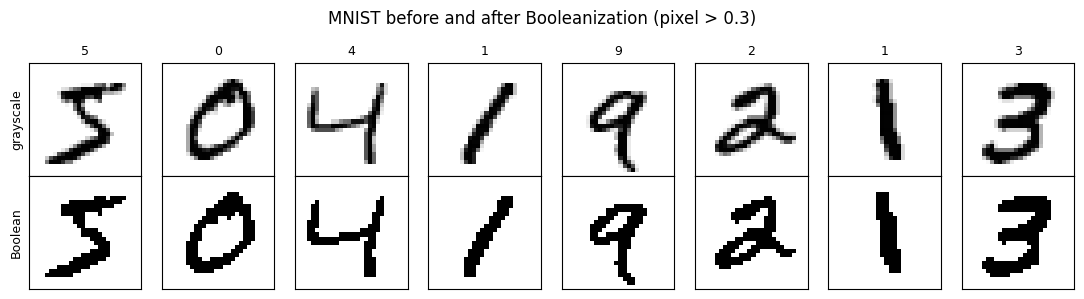

In [3]:
from torchvision.datasets import MNIST

raw = MNIST(root=DATA_ROOT, train=True, download=True).data.float() / 255.0

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for j in range(8):
    axes[0, j].imshow(raw[j], cmap="gray_r", interpolation="nearest")
    axes[0, j].set_title(int(y_train[j]), fontsize=9)
    axes[1, j].imshow(x_train[j, 0].float().cpu(), cmap="gray_r", interpolation="nearest")
    for r in (0, 1):
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
axes[0, 0].set_ylabel("grayscale", fontsize=9)
axes[1, 0].set_ylabel("Boolean", fontsize=9)
plt.suptitle("MNIST before and after Booleanization (pixel > 0.3)")
plt.tight_layout()
plt.show()

## 2. A flat Tsetlin machine

Each class owns `n_clauses` clauses; half vote for the class, half against it. With 784 pixels
the literal space is 1568 (`x_k` and `NOT x_k`), and the automata live in one
`(n_classes * n_clauses, 1568)` integer tensor.

`T` should scale with the clause count: it is the number of votes that must agree before
feedback stops, so a large clause budget with a tiny `T` leaves most clauses idle.

In [4]:
tt.seed_everything(SEED)

flat = tt.TsetlinMachine(
    n_features=784,
    n_classes=10,
    n_clauses=500,          # per class -> 5000 clauses total
    T=25,
    s=10.0,
    weighted=True,          # integer clause weights: one clause can carry many votes
).to(device)

state_mb = flat.ta_state.numel() * flat.ta_state.element_size() / 2**20
print(flat)
print(f"\nautomata: {tuple(flat.ta_state.shape)} = {flat.ta_state.numel():,} Tsetlin automata "
      f"({state_mb:.0f} MB)")

TsetlinMachine(n_classes=10, n_clauses_per_class=500, T=25.0, weighted=True, n_features=784, n_clauses_total=5000, n_states=128, s=10.0)

automata: (5000, 1568) = 7,840,000 Tsetlin automata (30 MB)


In [5]:
trainer = tt.Trainer(flat, batch_size=100, callbacks=[tt.StateSummaryLogger()], verbose=True)

t0 = time.time()
history_flat = trainer.fit((x_train_flat, y_train), epochs=10, val_data=(x_test_flat, y_test))
elapsed = time.time() - t0

print(f"\n{elapsed:.1f}s total | {10 * len(x_train_flat) / elapsed:,.0f} examples/s")

epoch   1 |    1.9s | batch_accuracy=0.8344 val_accuracy=0.8985 included_literals_mean=7.1724 empty_clauses=77


epoch   2 |    1.6s | batch_accuracy=0.8917 val_accuracy=0.9136 included_literals_mean=5.5844 empty_clauses=92


epoch   3 |    1.6s | batch_accuracy=0.9024 val_accuracy=0.9224 included_literals_mean=4.8014 empty_clauses=106


epoch   4 |    1.6s | batch_accuracy=0.9087 val_accuracy=0.9173 included_literals_mean=4.3042 empty_clauses=102


epoch   5 |    1.6s | batch_accuracy=0.9121 val_accuracy=0.9285 included_literals_mean=3.9844 empty_clauses=112


epoch   6 |    1.6s | batch_accuracy=0.9198 val_accuracy=0.9296 included_literals_mean=3.7486 empty_clauses=142


epoch   7 |    1.6s | batch_accuracy=0.9222 val_accuracy=0.9362 included_literals_mean=3.6664 empty_clauses=121


epoch   8 |    1.6s | batch_accuracy=0.9245 val_accuracy=0.9364 included_literals_mean=3.4864 empty_clauses=135


epoch   9 |    1.6s | batch_accuracy=0.9270 val_accuracy=0.9191 included_literals_mean=3.3204 empty_clauses=140


epoch  10 |    1.6s | batch_accuracy=0.9299 val_accuracy=0.9409 included_literals_mean=3.3722 empty_clauses=131

15.9s total | 37,708 examples/s


In [6]:
flat_metrics = trainer.evaluate((x_test_flat, y_test))
print("flat TM:", flat_metrics)

flat.eval()
votes_flat = flat(x_test_flat)
print()
print(tt.metrics.classification_report(votes_flat, y_test))

flat TM: {'accuracy': 0.9408999681472778}

           precision  recall  f1-score  support
0          0.884      0.991   0.934     980
1          0.971      0.990   0.980     1135
2          0.949      0.950   0.949     1032
3          0.904      0.954   0.929     1010
4          0.942      0.951   0.946     982
5          0.956      0.896   0.925     892
6          0.965      0.921   0.942     958
7          0.948      0.930   0.939     1028
8          0.958      0.897   0.927     974
9          0.942      0.917   0.929     1009

accuracy   0.941
macro avg  0.942      0.940   0.940     10000


> For reference, the literature reports ≈ 98 % for a flat Tsetlin machine with 2000 clauses per
> class trained for a few hundred epochs. Clause budget and epochs are the two dials that close
> that gap, and both cost linear time — see `docs/benchmarks.md` in this repository.

## 3. What does a flat clause look like?

The closed-form global importance (Blakely & Granmo, 2020) asks, per class, how much of the
positive clause weight rests on each literal. For MNIST each literal *is* a pixel, so the
importance vector reshapes straight back into a 28×28 image: the first 784 entries are the
"pixel must be ON" evidence, the last 784 the "pixel must be OFF" evidence.

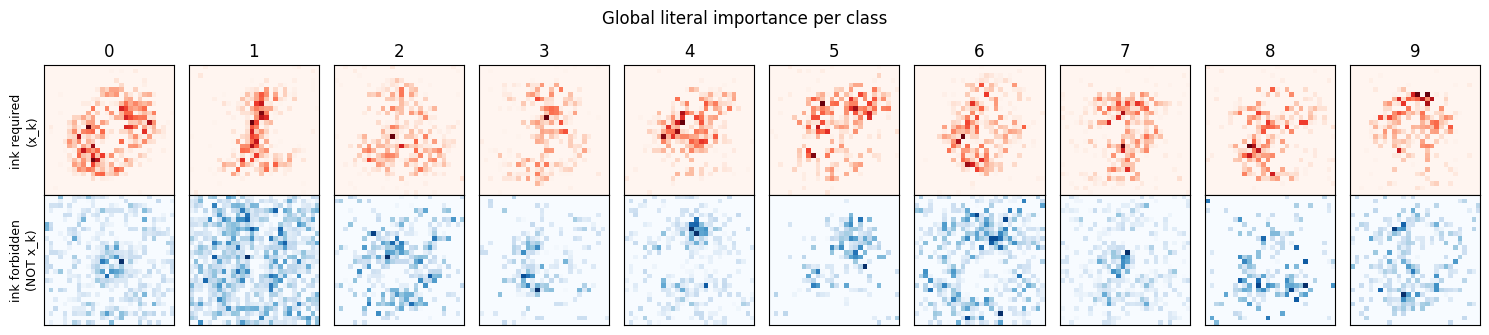

In [7]:
imp = tt.interpret.global_feature_importance(flat)          # (10, 1568)
pos, neg = imp[:, :784].reshape(10, 28, 28).cpu(), imp[:, 784:].reshape(10, 28, 28).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for k in range(10):
    axes[0, k].imshow(pos[k], cmap="Reds", interpolation="nearest")
    axes[0, k].set_title(str(k))
    axes[1, k].imshow(neg[k], cmap="Blues", interpolation="nearest")
    for r in (0, 1):
        axes[r, k].set_xticks([]); axes[r, k].set_yticks([])
axes[0, 0].set_ylabel("ink required\n(x_k)", fontsize=9)
axes[1, 0].set_ylabel("ink forbidden\n(NOT x_k)", fontsize=9)
plt.suptitle("Global literal importance per class")
plt.tight_layout()
plt.show()

The top row is a blurry prototype of each digit — the pixels the class's clauses insist must be
inked. The bottom row is the more interesting one: the pixels that must be *blank*. That is how
a `0` is separated from an `8` (the centre must stay empty) and a `1` from a `7` (no horizontal
bar). A linear model has one weight per pixel and cannot express "inked here AND blank there"
as a single unit; a clause can, because it is a conjunction.

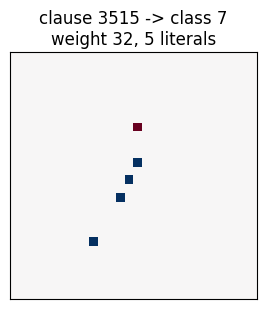

In [8]:
# One concrete clause, as a 28x28 map: red = pixel must be ON, blue = must be OFF.
best = int(flat.weights[flat.clause_polarity > 0].argmax())
clause = int(torch.nonzero(flat.clause_polarity > 0).flatten()[best])
mask = flat.included_mask()[clause].cpu()
patch = (mask[:784].int() - mask[784:].int()).reshape(28, 28)

fig, ax = plt.subplots(figsize=(3.2, 3.2))
ax.imshow(patch, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"clause {clause} -> class {int(flat.clause_class[clause])}\n"
             f"weight {int(flat.weights[clause])}, {int(flat.include_count[clause])} literals")
plt.tight_layout()
plt.show()

## 4. The convolutional Tsetlin machine

A flat machine sees 784 independent pixels, so a stroke shifted by two pixels is a different
pattern and needs its own clauses. `ConvTsetlinMachine` instead evaluates every clause on every
`patch_size × patch_size` window of the image:

* A clause is **True for the image** if it matches **at least one** patch.
* For learning, one randomly chosen *matching* patch supplies the literals (Granmo et al., 2019).
* With `position_encoding=True` each patch also carries thermometer-encoded coordinates, so a
  clause can say "this stroke, in the upper half". That helps when position is informative
  (digits are centred) and hurts on translation-invariant problems.

The cost: each image becomes `P` patches (361 for a 10×10 window on 28×28), so one update does
`P` times the clause evaluations of a flat model. The model chunks batches automatically to keep
intermediates inside `max_chunk_elements`.

In [9]:
tt.seed_everything(SEED)

conv = tt.ConvTsetlinMachine(
    n_classes=10,
    n_clauses=200,              # per class
    T=100,
    s=10.0,
    patch_size=10,
    stride=1,
    position_encoding=True,
    input_shape=(1, 28, 28),
    weighted=True,
).to(device)

print(conv)
print(f"\npatches per image: {(28 - 10 + 1) ** 2}")
print(f"Boolean features per patch: {conv.n_features} "
      f"(= 10x10 pixels + {(28 - 10 + 1) - 1} y-bits + {(28 - 10 + 1) - 1} x-bits)")

ConvTsetlinMachine(patch_size=(10, 10), stride=(1, 1), position_encoding=True, input_shape=(1, 28, 28), n_classes=10, n_clauses_per_class=200, T=100.0, weighted=True, n_features=136, n_clauses_total=2000, n_states=128, s=10.0)

patches per image: 361
Boolean features per patch: 136 (= 10x10 pixels + 18 y-bits + 18 x-bits)


In [10]:
conv_trainer = tt.Trainer(conv, batch_size=100, verbose=True)

t0 = time.time()
history_conv = conv_trainer.fit((x_train, y_train), epochs=10, val_data=(x_test, y_test))
elapsed_conv = time.time() - t0

conv_metrics = conv_trainer.evaluate((x_test, y_test))
print(f"\n{elapsed_conv:.1f}s total | {10 * len(x_train) / elapsed_conv:,.0f} examples/s")
print("conv TM:", conv_metrics)

epoch   1 |    5.3s | batch_accuracy=0.8934 val_accuracy=0.9544


epoch   2 |    5.3s | batch_accuracy=0.9615 val_accuracy=0.9671


epoch   3 |    5.3s | batch_accuracy=0.9690 val_accuracy=0.9684


epoch   4 |    5.3s | batch_accuracy=0.9724 val_accuracy=0.9725


epoch   5 |    5.3s | batch_accuracy=0.9761 val_accuracy=0.9735


...

epoch   7 |    5.3s | batch_accuracy=0.9791 val_accuracy=0.9772


epoch   8 |    5.3s | batch_accuracy=0.9802 val_accuracy=0.9774


epoch   9 |    5.3s | batch_accuracy=0.9812 val_accuracy=0.9784


epoch  10 |    5.3s | batch_accuracy=0.9809 val_accuracy=0.9779



53.1s total | 11,299 examples/s
conv TM: {'accuracy': 0.977899968624115}


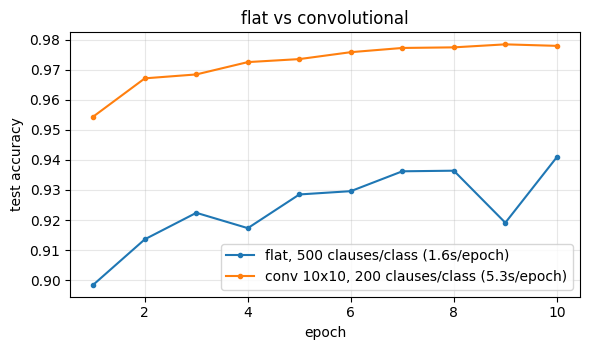

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot([1 + i for i in range(len(history_flat))], history_flat["val_accuracy"],
        marker=".", label=f"flat, 500 clauses/class ({elapsed / 10:.1f}s/epoch)")
ax.plot([1 + i for i in range(len(history_conv))], history_conv["val_accuracy"],
        marker=".", label=f"conv 10x10, 200 clauses/class ({elapsed_conv / 10:.1f}s/epoch)")
ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("flat vs convolutional")
plt.tight_layout()
plt.show()

The convolutional machine wins with **less than half the clauses**, and it gets most of the way
there in a single epoch. Sharing one clause across all 361 positions is simply a much better use
of the clause budget than learning the same stroke 361 times.

### The clauses are patches you can look at

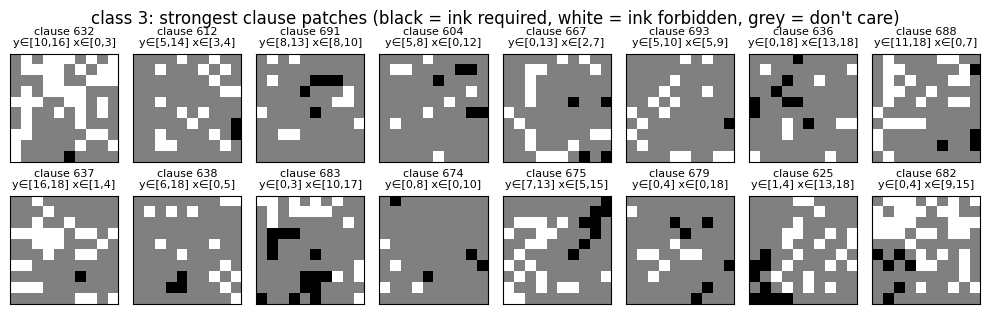

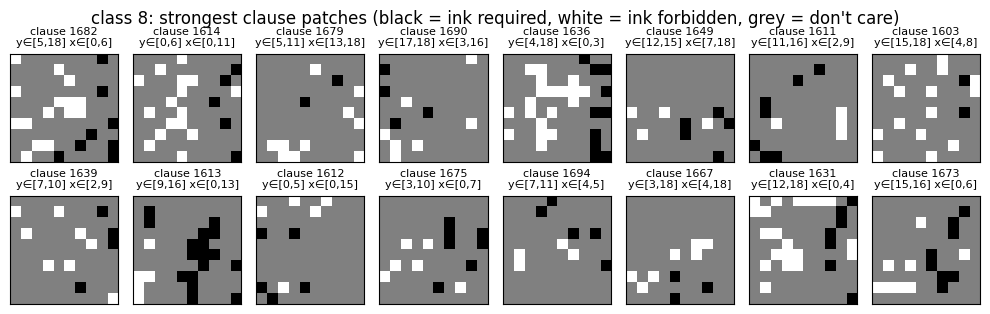

In [12]:
# The 24 highest-weight positive clauses of class 3 and class 8.
for digit in (3, 8):
    mask = ((conv.clause_class == digit) & (conv.clause_polarity > 0) & (conv.include_count > 0))
    idx = torch.nonzero(mask).flatten()
    top = idx[conv.weights[idx].argsort(descending=True)][:16].tolist()
    fig = tt.viz.plot_conv_clauses(conv, top, ncols=8, figsize_per=1.25)
    fig.suptitle(f"class {digit}: strongest clause patches "
                 f"(black = ink required, white = ink forbidden, grey = don't care)", y=1.02)
    plt.show()

Each panel is one 10×10 rule and its title reports the patch-grid region the position literals
allow. These are stroke detectors — corners, junctions, bars — restricted to the part of the
image where that stroke is diagnostic.

## 5. Evaluation: errors, confidence, abstention

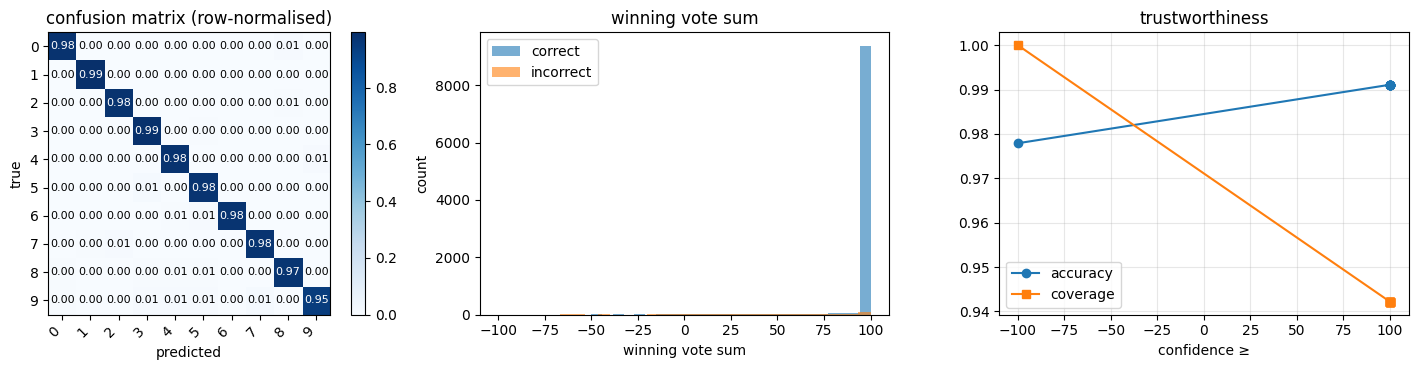

most frequent confusions:
  true 9 -> predicted 7: 15
  true 5 -> predicted 3: 13
  true 4 -> predicted 9: 11
  true 9 -> predicted 3: 10
  true 6 -> predicted 5: 10
  true 9 -> predicted 4: 9


In [13]:
conv.eval()
votes = conv(x_test)
pred = votes.argmax(1)
cm = tt.metrics.confusion_matrix(votes, y_test, n_classes=10)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
tt.viz.plot_confusion_matrix(cm, normalize=True, ax=axes[0])
axes[0].set_title("confusion matrix (row-normalised)")
tt.viz.plot_votes(votes, y_test, ax=axes[1])
axes[1].set_title("winning vote sum")
curve = tt.metrics.trustworthiness_curve(votes, y_test, n_levels=10)
tt.viz.plot_trustworthiness(curve, ax=axes[2])
axes[2].set_title("trustworthiness")
plt.tight_layout()
plt.show()

# The pairs the model actually confuses.
off = cm.clone()
off.fill_diagonal_(0)
pairs = torch.topk(off.flatten(), 6)
print("most frequent confusions:")
for count, flat_idx in zip(pairs.values.tolist(), pairs.indices.tolist()):
    print(f"  true {flat_idx // 10} -> predicted {flat_idx % 10}: {count}")

In [14]:
# Confidence-based abstention: keep only predictions whose vote margin is large enough.
margin = tt.metrics.vote_margin(votes)
correct = (pred == y_test)
print(f"{'coverage':>10s}  {'accuracy':>9s}")
for q in (0.0, 0.05, 0.10, 0.25):
    keep = margin >= torch.quantile(margin.float(), q)
    print(f"{keep.float().mean():>9.0%}   {correct[keep].float().mean():>9.4f}")

  coverage   accuracy
     100%      0.9779
      95%      0.9934
      90%      0.9977
      75%      0.9995


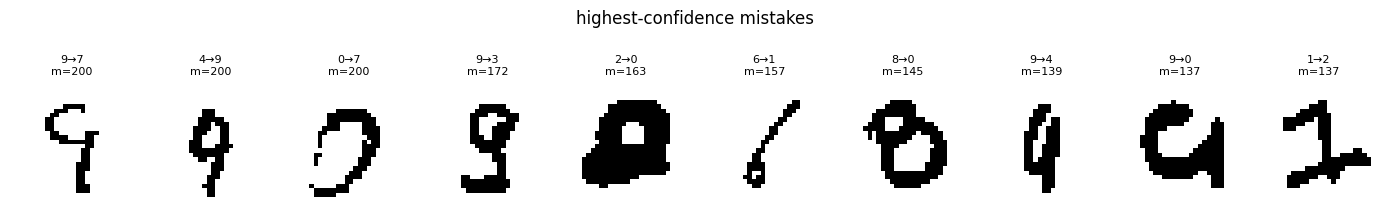

In [15]:
# The errors the model is most confident about — these are the genuinely hard images.
wrong = torch.nonzero(~correct).flatten()
order = wrong[margin[wrong].argsort(descending=True)][:10]

fig, axes = plt.subplots(1, 10, figsize=(14, 1.9))
for ax, i in zip(axes, order.tolist()):
    ax.imshow(x_test[i, 0].float().cpu(), cmap="gray_r", interpolation="nearest")
    ax.set_title(f"{int(y_test[i])}→{int(pred[i])}\nm={margin[i]:.0f}", fontsize=8)
    ax.axis("off")
plt.suptitle("highest-confidence mistakes", y=1.12)
plt.tight_layout()
plt.show()

## 6. Experiment 1 — the booleanization decides the ceiling

`pixel > 0.3` is one choice. `AdaptiveThresholdEncoder` compares each pixel to a *local* mean
(the OpenCV `ADAPTIVE_THRESH_GAUSSIAN_C` rule), which is the standard trick for CIFAR-style
images with varying brightness. On MNIST — already black-on-white and normalised — it mostly
adds noise. One epoch each with a small convolutional machine is enough to see it.

In [16]:
rows = []
variants = {
    "global threshold 0.3": dict(threshold=0.3),
    "global threshold 0.5": dict(threshold=0.5),
    "global threshold 0.1": dict(threshold=0.1),
    "adaptive (block 11, C=0.008)": dict(encoder=tt.data.AdaptiveThresholdEncoder(11, 0.008).to(device)),
    "adaptive (block 11, C=0.05)": dict(encoder=tt.data.AdaptiveThresholdEncoder(11, 0.05).to(device)),
}

for name, kwargs in variants.items():
    tt.seed_everything(SEED)
    xtr, ytr = tt.data.load_mnist_boolean(DATA_ROOT, train=True, device=device, **kwargs)
    xte, yte = tt.data.load_mnist_boolean(DATA_ROOT, train=False, device=device, **kwargs)
    m = tt.ConvTsetlinMachine(10, 100, T=50, s=10.0, patch_size=10,
                              input_shape=(1, 28, 28), weighted=True).to(device)
    tr = tt.Trainer(m, batch_size=100, verbose=False)
    t0 = time.time()
    tr.fit((xtr, ytr), epochs=1)
    rows.append({"booleanization": name,
                 "pixels ON": round(float(xtr.float().mean()), 3),
                 "accuracy (1 epoch)": round(tr.evaluate((xte, yte))["accuracy"], 4),
                 "seconds": round(time.time() - t0, 1)})

pd.DataFrame(rows)

,booleanization,pixels ON,accuracy (1 epoch),seconds
0,global threshold 0.3,0.151,0.9383,3.6
1,global threshold 0.5,0.132,0.9370,3.6
2,global threshold 0.1,0.174,0.9381,3.5
3,"adaptive (block 11, C=0.008)",0.561,0.9270,3.6
4,"adaptive (block 11, C=0.05)",0.712,0.9217,3.6


The "pixels ON" column is the thing to watch. The exact global threshold barely matters — 0.1,
0.3 and 0.5 all land within noise of each other, because MNIST strokes are saturated. What costs
accuracy is switching to a scheme that turns *most* pixels on: adaptive thresholding fires on
55–70 % of the pixels and destroys the sparsity that made the digit legible, so every patch looks
similar and clauses need more literals to discriminate.

That is a property of this dataset, not a verdict on adaptive thresholding. MNIST is already
black-on-white with uniform illumination, which is exactly the situation a local threshold is
useless in. For photographs (see the CIFAR-10 notebook) the trade-off flips.

## 7. Experiment 2 — batch size trades fidelity for throughput

This is the one TM-specific pitfall of a GPU implementation. In the classical algorithm every
example updates the automata before the next is evaluated. `torchtsetlin` defaults to
`feedback_mode="batch"`: it evaluates the whole mini-batch against the *current* automata,
accumulates the Type I / Type II events and applies them once. That is what makes the GPU
version fast — and it is an approximation, exactly like mini-batch SGD.

In [17]:
rows = []
for bs in (10, 50, 100, 500, 2000):
    tt.seed_everything(SEED)
    m = tt.TsetlinMachine(784, 10, 200, T=25, s=10.0, weighted=True).to(device)
    tr = tt.Trainer(m, batch_size=bs, verbose=False)
    t0 = time.time()
    tr.fit((x_train_flat, y_train), epochs=3)
    secs = time.time() - t0
    rows.append({"batch size": bs,
                 "accuracy (3 epochs)": round(tr.evaluate((x_test_flat, y_test))["accuracy"], 4),
                 "examples/s": int(3 * len(x_train_flat) / secs),
                 "seconds": round(secs, 1)})
pd.DataFrame(rows)

,batch size,accuracy (3 epochs),examples/s,seconds
0,10,0.9129,6155,29.2
1,50,0.9109,30008,6.0
2,100,0.9237,59405,3.0
3,500,0.9117,240410,0.7
4,2000,0.7996,444723,0.4


Throughput rises by almost two orders of magnitude across this range while accuracy stays flat
— until the batch gets large enough that many examples send contradictory feedback to the same
clause before any of it is applied, and accuracy falls off a cliff. Batches of 50–200 are the
sweet spot for MNIST. If you need the exact classical
algorithm — for reproducing a paper, say — pass `feedback_mode="sequential"` (or
`model.update(x, y, sequential=True)`) and accept roughly two orders of magnitude less
throughput.

In [18]:
# Same data, same clause budget, same epochs -- only the feedback mode differs.
# Run on a 10k subset so the sequential version finishes in well under a minute.
sub_x, sub_y = x_train_flat[:10_000], y_train[:10_000]
EPOCHS = 3

for mode in ("sequential", "batch"):
    tt.seed_everything(SEED)
    m = tt.TsetlinMachine(784, 10, 200, T=25, s=10.0, weighted=True,
                          feedback_mode=mode).to(device)
    t0 = time.time()
    tt.Trainer(m, batch_size=100, verbose=False).fit((sub_x, sub_y), epochs=EPOCHS)
    secs = time.time() - t0
    acc = tt.metrics.accuracy(m.eval()(x_test_flat), y_test)
    print(f"{mode:>10s}: {secs:7.2f}s  ({EPOCHS * len(sub_x) / secs:7.0f} ex/s)  "
          f"test accuracy {acc:.4f}")

sequential:   33.03s  (    908 ex/s)  test accuracy 0.8761


     batch:    0.51s  (  59084 ex/s)  test accuracy 0.8756


## 8. Explaining a prediction, and saving

true 7 | predicted 7 | votes [-100, -100, -100, -100, -100, -100, -100, 100, -100, -100]
5 of the strongest matching clauses shown below


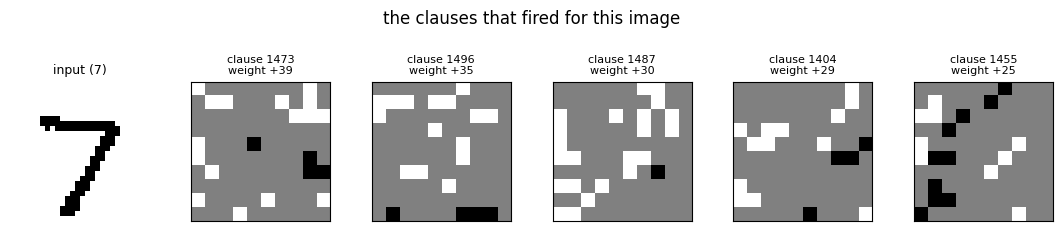

In [19]:
# Note: vote sums are clamped to [-T, T], so a confident prediction saturates at +/-T.
i = 0
expl = tt.interpret.explain(conv, x_test[i], max_clauses=5)
print(f"true {int(y_test[i])} | predicted {expl.prediction} | "
      f"votes {[round(v) for v in expl.votes]}")
print(f"{len(expl.matched)} of the strongest matching clauses shown below")

fig, axes = plt.subplots(1, 6, figsize=(11, 2.1))
axes[0].imshow(x_test[i, 0].float().cpu(), cmap="gray_r", interpolation="nearest")
axes[0].set_title(f"input ({int(y_test[i])})", fontsize=9)
axes[0].axis("off")
for ax, m in zip(axes[1:], expl.matched):
    tt.viz.plot_conv_clause(conv, m.clause, ax=ax, show_region=False)
    ax.set_title(f"clause {m.clause}\nweight {m.weight:+.0f}", fontsize=8)
plt.suptitle("the clauses that fired for this image", y=1.08)
plt.tight_layout()
plt.show()

In [20]:
torch.save(conv.state_dict(), "mnist_conv_tm.pt")

restored = tt.ConvTsetlinMachine(10, 200, T=100, s=10.0, patch_size=10,
                                 input_shape=(1, 28, 28), weighted=True)
restored.load_state_dict(torch.load("mnist_conv_tm.pt", weights_only=True))
restored = restored.to(device).eval()
print("restored accuracy:", tt.metrics.accuracy(restored(x_test), y_test))

print("\nsummary")
print(f"  flat TM  (500 clauses/class, 10 epochs): {flat_metrics['accuracy']:.4f} "
      f"in {elapsed:.0f}s")
print(f"  conv TM  (200 clauses/class, 10 epochs): {conv_metrics['accuracy']:.4f} "
      f"in {elapsed_conv:.0f}s")

restored accuracy: 0.977899968624115

summary
  flat TM  (500 clauses/class, 10 epochs): 0.9409 in 16s
  conv TM  (200 clauses/class, 10 epochs): 0.9779 in 53s


## Takeaways

* **Convolution is the right inductive bias here too.** 200 shared clauses per class beat 500
  position-specific ones, because a clause that matches "at least one patch" is reused across
  all 361 window positions.
* **Booleanization sets the ceiling.** Watch the fraction of pixels that end up ON: a
  booleanization that fires on most pixels throws away the structure the clauses need.
* **Batch size is a fidelity knob, not just a speed knob.** Large batches accumulate
  contradictory feedback; 50–200 is the useful range, and `feedback_mode="sequential"` is there
  when you need the exact algorithm.
* **The model stays inspectable at scale.** 5000 clauses is a lot of rules, but each one is
  still a patch you can plot, and the closed-form importance turns the whole class into a single
  image.

Next: [`03_cifar10_tsetlin.ipynb`](03_cifar10_tsetlin.ipynb) — colour images, where
booleanization stops being an afterthought and the honest accuracy numbers get a lot lower.